**PROJECT # 15**


**STUDENT FEEDBACK ANALYSIS (NAIVE BAYES)**

In [53]:
pip install pandas scikit-learn nltk


In [63]:
import pandas as pd

df = pd.read_csv("student_feedback_1000_v3.csv")
print(df.head())

  student_id department            subject  \
0    STU0001       MATH           Calculus   
1    STU0002         SE             DevOps   
2    STU0003         EE   Circuit Analysis   
3    STU0004       MATH         Statistics   
4    STU0005         EE  Signals & Systems   

                                       feedback_text sentiment_label  \
0  The instructor breaks complex concepts into ma...        positive   
1  This faculty member structures every lecture s...        positive   
2  The lecturer goes beyond slides and adds real ...        positive   
3  This course's teacher doesn't engage with stud...        negative   
4  This faculty member explains even difficult to...        positive   

       emotion feedback_type  
0          joy      Teaching  
1          joy      Teaching  
2          joy      Teaching  
3  frustration      Teaching  
4          joy      Teaching  


In [64]:
import nltk
import string
from nltk.corpus import stopwords

PREPROCESSING


In [65]:
import string
from nltk.corpus import stopwords

def clean_text(text):
    text = text.lower()
    text = "".join([char for char in text if char not in string.punctuation])
    words = text.split()
    words = [word for word in words if word not in stopwords.words('english')]
    return " ".join(words)

df['cleaned_text'] = df['feedback_text'].apply(clean_text)

Convert Text → Numbers (TF-IDF)

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer


vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=3000,

)

X = vectorizer.fit_transform(df['cleaned_text'])

y = df['sentiment_label']

In [67]:
from sklearn.utils import resample
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import ComplementNB

model = ComplementNB()

Train Naive Bayes Model

In [72]:
import numpy as np
#  Cross-validation
from sklearn.model_selection import cross_val_score

y = df['sentiment_label']

scores = cross_val_score(model, X, y, cv=5)
print("Mean CV Accuracy:", scores.mean())


# Train-test split (for detailed evaluation)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Mean CV Accuracy: 0.9259999999999999


In [85]:
model2=MultinomialNB()
scores = cross_val_score(model2, X, y, cv=5)
print("Mean CV Accuracy (MultinomialNB):", scores.mean() )

Mean CV Accuracy (MultinomialNB): 0.9369999999999999


As the accuracy score of Multinomial is greater, we will be using it for confusion matrix

TEST ACCURACY

In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


### Classification Report for Multinomial Naive Bayes Model

In [96]:
model2.fit(X_train, y_train)
y_pred_multinomial = model2.predict(X_test)
print(classification_report(y_test, y_pred_multinomial))

              precision    recall  f1-score   support

    negative       1.00      0.94      0.97        98
     neutral       0.88      1.00      0.93        35
    positive       0.99      1.00      0.99        67

    accuracy                           0.97       200
   macro avg       0.95      0.98      0.96       200
weighted avg       0.97      0.97      0.97       200



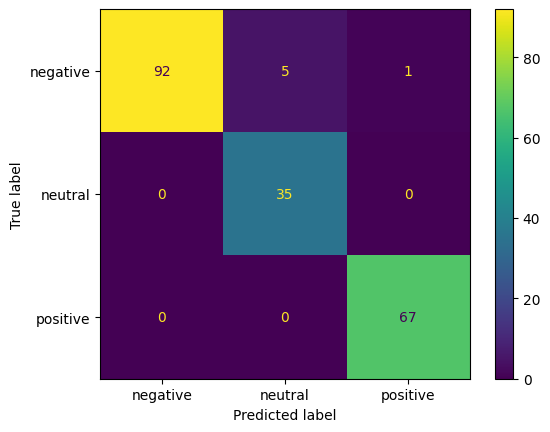

In [97]:
labels = ['negative', 'neutral', 'positive']

cm = confusion_matrix(y_test, y_pred_multinomial, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.show()

Visualizations

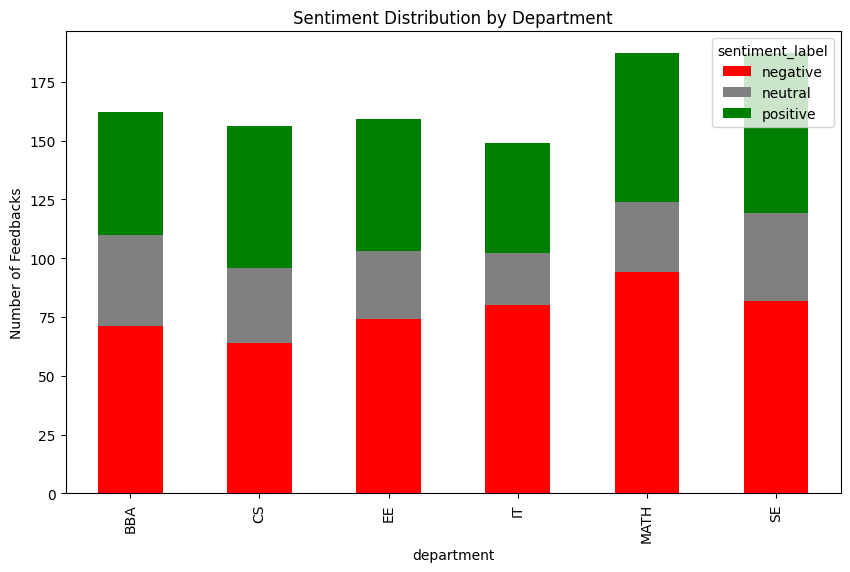

In [98]:
import seaborn as sns

# Create a pivot table of Department vs Sentiment
dept_sentiment = df.groupby(['department', 'sentiment_label']).size().unstack()

# Plot it
dept_sentiment.plot(kind='bar', stacked=True, figsize=(10, 6), color=['red', 'gray', 'green'])
plt.title("Sentiment Distribution by Department")
plt.ylabel("Number of Feedbacks")
plt.show()


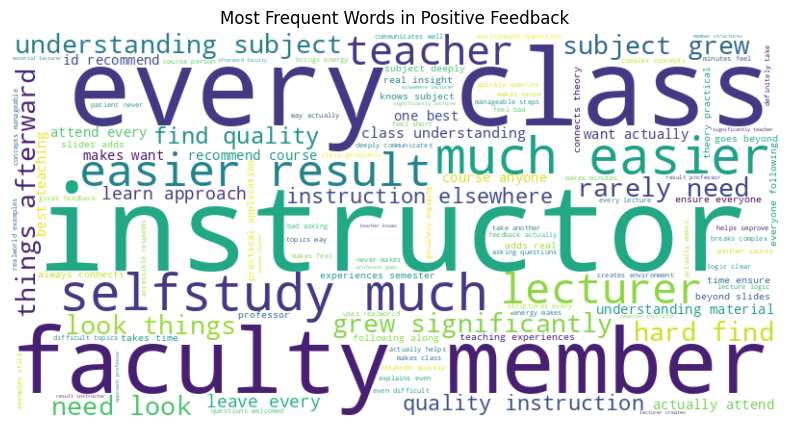

In [99]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all positive feedback into one big string
pos_text = " ".join(df[df['sentiment_label'] == 'positive']['cleaned_text'])

# Create and display the Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(pos_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in Positive Feedback")
plt.show()
